# Per-Time-Bin Decoding (no stimulus averaging)

Same overall procedure as `File_cleaned_layers.ipynb`, but every temporal
bin within every trial is an **individual sample**. This:

- Preserves temporal structure inside each trial
- Increases sample count ~50x (enough for t-SNE / UMAP / CEBRA to be meaningful)
- Lets CEBRA actually see a time series (its real use case)
- Forces cross-validation to group by trial (`GroupKFold`) so frames from the
  same trial cannot leak across folds
- Evaluates classifiers in the **full PCA-50 space**, not on 2-D embeddings


imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from collections import defaultdict, Counter
import warnings, h5py
warnings.filterwarnings('ignore')

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (silhouette_score, balanced_accuracy_score, f1_score,
                             confusion_matrix, ConfusionMatrixDisplay, classification_report)
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, cross_val_predict, GroupKFold
from sklearn.pipeline import Pipeline
from scipy.stats import ttest_1samp

try:
    import umap
    UMAP_AVAILABLE = True
except ImportError:
    UMAP_AVAILABLE = False

try:
    import cebra
    CEBRA_AVAILABLE = True
except ImportError:
    CEBRA_AVAILABLE = False

%load_ext autoreload
%autoreload 2
import microns_datacleaner as mic
import microns_datacleaner.filters as fl


In [2]:
plt.rcParams.update({
    'figure.dpi': 120, 'font.size': 11, 'axes.titlesize': 13,
    'axes.labelsize': 12, 'axes.spines.top': False,
    'axes.spines.right': False, 'legend.frameon': False, 'savefig.bbox': 'tight',
})
SEED    = 42
SESSION = '9_4'

# === Temporal binning ===
# Each trial has many frames; we bin BIN_SIZE consecutive frames together
# (mean inside the bin -> denoising) and emit one sample per bin.
BIN_SIZE = 5      # frames per bin
MIN_BINS = 2      # drop trials shorter than this many bins

# === Pipeline knobs ===
N_PCS_FOR_CLF   = 50    # classifier evaluated in this PCA space
N_PCS_FOR_TSNE  = 50    # input to t-SNE / UMAP
N_CV_SPLITS     = 5
N_SHUFFLES      = 50


metadata, filter (identical to original)

In [3]:
cleaner = mic.MicronsDataCleaner(datadir='data/', version=1718)
cleaner.download_nucleus_data()

units, segments = cleaner.process_nucleus_data(functional_data='best_only')
v1_neurons = fl.filter_neurons(units, brain_area='V1', proofread='ax_clean', tuning='matched')
print(f'V1 neurons (proofread + matched tuning): {len(v1_neurons)}')

with h5py.File('microns.h5', 'r') as f:
    session_unit_ids = f['sessions'][SESSION]['meta']['unit_ids'][:]

v1_with_uid = v1_neurons.dropna(subset=['unit_id']).copy()
v1_with_uid['unit_id_int'] = v1_with_uid['unit_id'].astype(int)
trusted_unit_ids = set(v1_with_uid['unit_id_int'].values)
keep_neuron_cols = np.where(np.isin(session_unit_ids, list(trusted_unit_ids)))[0]
print(f'Trusted neurons in session: {len(keep_neuron_cols)} / {len(session_unit_ids)}')

uid_to_meta = v1_with_uid.drop_duplicates(subset=['unit_id_int']).set_index('unit_id_int')

def _meta(uid, col):
    if uid in uid_to_meta.index:
        v = uid_to_meta.at[uid, col]
        return str(v) if not isinstance(v, str) else v
    return 'unknown'

trusted_meta = pd.DataFrame([
    {'unit_id': int(uid),
     'layer':   _meta(uid, 'layer'),
     'classification_system': _meta(uid, 'classification_system')}
    for uid in session_unit_ids[keep_neuron_cols]
])
print(trusted_meta['layer'].value_counts().to_string())


Transform positions: 100%|██████████| 94014/94014 [00:02<00:00, 38226.92it/s]


V1 neurons (proofread + matched tuning): 728
Trusted neurons in session: 579 / 7855
layer
L4      257
L2/3    220
L5       89
L6       12
L1        1


## Per-bin sample extraction

Replaces the single `mean(axis=1)` collapse in the original. Each row of
`R_matrix` is now a single time-bin of a single trial — labelled by the
stimulus type of that trial, and tagged with `trial_id` so we can do
group-wise cross-validation.


In [4]:
funcreader = mic.MicronsFunctionalReader(path='microns.h5')
hashes     = funcreader.get_hashes_by_session(SESSION)

print(f'Trials in session: {len(hashes)}')
print('Stimulus types:')
for k, v in sorted(Counter(funcreader.get_video_type(h) for h in hashes).items(),
                   key=lambda x: -x[1]):
    print(f'  {k:22s}: {v:4d}')


Trials in session: 464
Stimulus types:
  Clip                  :  384
  Monet2                :   40
  Trippy                :   40


In [5]:
# --- Per-bin extraction loop ---
bins_resp, bins_type, bins_hash, bins_trial, bins_t = [], [], [], [], []
n_failed = 0
n_trials_used = 0

print(f'Extracting bins (BIN_SIZE={BIN_SIZE} frames)...')
for trial_idx, h in enumerate(hashes):
    stype = funcreader.get_video_type(h)
    try:
        r = funcreader.get_trial(SESSION, trial_idx)
        if r is None or 'responses' not in r:
            n_failed += 1
            continue
        resp = r['responses'][keep_neuron_cols, :]            # (n_neurons, n_frames)
        n_frames = resp.shape[1]
        n_bins   = n_frames // BIN_SIZE
        if n_bins < MIN_BINS:
            continue
        # (n_bins, n_neurons): mean within each consecutive BIN_SIZE-frame window
        binned = (resp[:, :n_bins * BIN_SIZE]
                  .reshape(resp.shape[0], n_bins, BIN_SIZE)
                  .mean(axis=2)
                  .T)
        for b in range(n_bins):
            bins_resp.append(binned[b])
            bins_type.append(stype)
            bins_hash.append(h)
            bins_trial.append(trial_idx)
            bins_t.append(b)
        n_trials_used += 1
    except Exception:
        n_failed += 1

R_matrix   = np.array(bins_resp)                 # (n_bins_total, n_neurons)
labels_raw = np.array(bins_type)
hash_ids   = np.array(bins_hash)
trial_ids  = np.array(bins_trial)
time_idx   = np.array(bins_t)

print(f'\nTrials used:   {n_trials_used}  (skipped: {n_failed})')
print(f'Bins/sample:    {len(R_matrix)}')
print(f'R_matrix shape: {R_matrix.shape}')
print('\nBins per stimulus type:')
for k, v in sorted(Counter(labels_raw).items(), key=lambda x: -x[1]):
    print(f'  {k:22s}: {v:5d}')


Extracting bins (BIN_SIZE=5 frames)...

Trials used:   464  (skipped: 0)
Bins/sample:    7520
R_matrix shape: (7520, 579)

Bins per stimulus type:
  Clip                  :  5760
  Monet2                :   880
  Trippy                :   880


preprocessing

In [6]:
# Drop neurons with too many NaNs across all bins
nan_frac     = np.isnan(R_matrix).mean(axis=0)
keep_neurons = nan_frac < 0.10
R_clean      = R_matrix[:, keep_neurons].copy()
trusted_meta_clean = trusted_meta[keep_neurons].reset_index(drop=True)
print(f'Neurons retained: {keep_neurons.sum()} / {R_matrix.shape[1]}')

# Mean-impute remaining NaNs
col_means = np.nanmean(R_clean, axis=0)
nan_idx   = np.where(np.isnan(R_clean))
R_clean[nan_idx] = np.take(col_means, nan_idx[1])

# Drop bins that are totally flat across neurons (dead frames)
active    = R_clean.std(axis=1) > 1e-6
R_clean   = R_clean[active]
labels    = labels_raw[active]
hash_ids  = hash_ids[active]
trial_ids = trial_ids[active]
time_idx  = time_idx[active]
print(f'Bins after activity filter: {active.sum()} / {len(active)}')

# Standardize
scaler   = StandardScaler()
R_scaled = scaler.fit_transform(R_clean)
print(f'\nFinal feature matrix: {R_scaled.shape}')


Neurons retained: 579 / 579
Bins after activity filter: 7520 / 7520

Final feature matrix: (7520, 579)


In [7]:
unique_labels = sorted(set(labels))
n_types       = len(unique_labels)
palette       = plt.cm.get_cmap('tab10', n_types)
label_to_color = {lbl: palette(i) for i, lbl in enumerate(unique_labels)}
le            = LabelEncoder()
y             = le.fit_transform(labels)
counts        = {lbl: int((labels == lbl).sum()) for lbl in unique_labels}
majority_frac = max(counts.values()) / len(labels)
chance_level  = 1.0 / n_types
legend_patches = [Patch(color=label_to_color[l], label=l) for l in unique_labels]

print(f'Classes: {n_types}  |  chance = {chance_level:.3f}  |  majority = {majority_frac:.3f}')
for lbl, n in counts.items():
    print(f'  {lbl:22s}  n={n:5d}  ({100*n/len(labels):.1f}%)')
print(f'\nUnique trials: {len(np.unique(trial_ids))}  '
      f'(used as CV groups)')


Classes: 3  |  chance = 0.333  |  majority = 0.766
  Clip                    n= 5760  (76.6%)
  Monet2                  n=  880  (11.7%)
  Trippy                  n=  880  (11.7%)

Unique trials: 464  (used as CV groups)


## PCA

The big change here is that we now have thousands of samples instead of
hundreds, so the leading PCs are far better estimated.


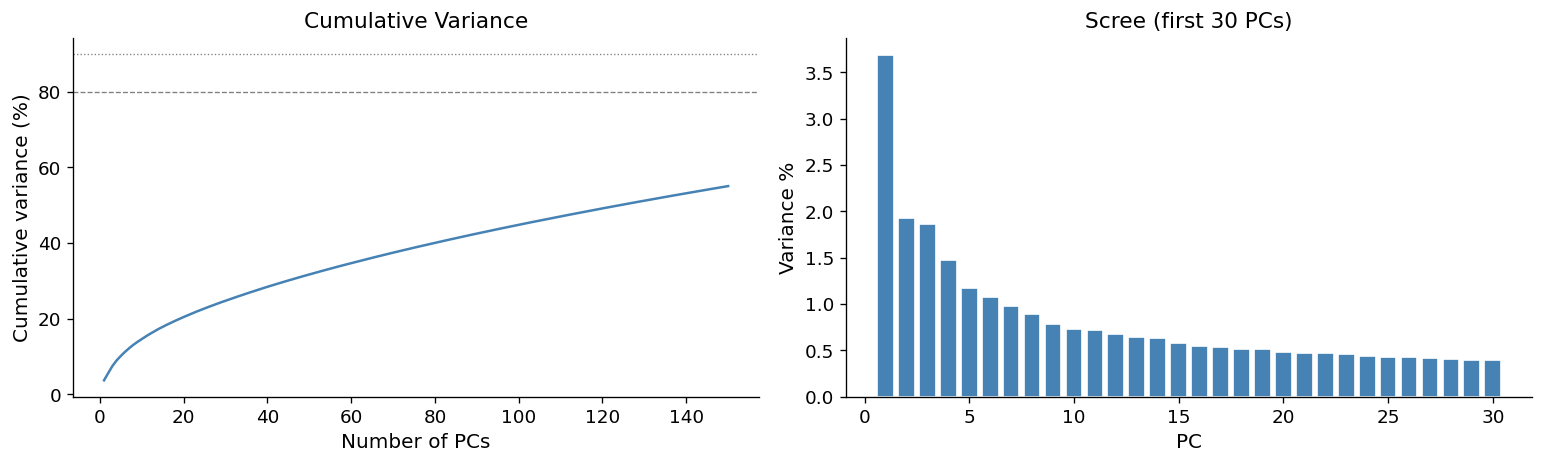

PCs for 80% var: 151   PCs for 90% var: 151
PC1+PC2: 5.62%   Participation ratio: 239.4


In [8]:
n_pcs = min(150, R_scaled.shape[0]-1, R_scaled.shape[1]-1)
pca   = PCA(n_components=n_pcs, random_state=SEED)
R_pca = pca.fit_transform(R_scaled)
cumvar = np.cumsum(pca.explained_variance_ratio_)
ev     = pca.explained_variance_ratio_
participation_ratio = 1.0 / np.sum(ev ** 2)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(np.arange(1, n_pcs+1), cumvar*100, color='steelblue')
axes[0].set_xlabel('Number of PCs'); axes[0].set_ylabel('Cumulative variance (%)')
axes[0].axhline(80, color='gray', ls='--', lw=0.8)
axes[0].axhline(90, color='gray', ls=':',  lw=0.8)
axes[0].set_title('Cumulative Variance')

axes[1].bar(np.arange(1, 31), ev[:30]*100, color='steelblue', edgecolor='white')
axes[1].set_xlabel('PC'); axes[1].set_ylabel('Variance %')
axes[1].set_title('Scree (first 30 PCs)')
plt.tight_layout(); plt.savefig('fig_ts_pca_variance.png', dpi=150); plt.show()

n80 = int(np.searchsorted(cumvar, 0.80)) + 1
n90 = int(np.searchsorted(cumvar, 0.90)) + 1
print(f'PCs for 80% var: {n80}   PCs for 90% var: {n90}')
print(f'PC1+PC2: {cumvar[1]*100:.2f}%   Participation ratio: {participation_ratio:.1f}')


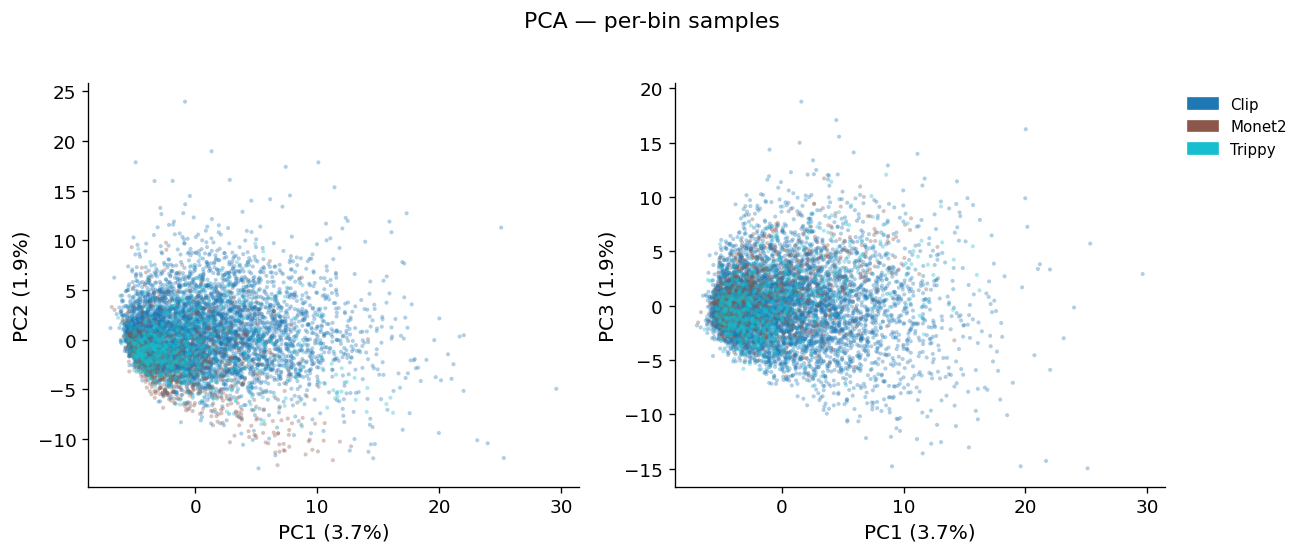

In [9]:
# Scatter coloured by class
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for xi, yi, ax in [(0,1,axes[0]), (0,2,axes[1])]:
    for lbl in unique_labels:
        m = labels == lbl
        ax.scatter(R_pca[m,xi], R_pca[m,yi],
                   color=label_to_color[lbl], alpha=0.35, s=6, edgecolors='none')
    ax.set_xlabel(f'PC{xi+1} ({ev[xi]*100:.1f}%)')
    ax.set_ylabel(f'PC{yi+1} ({ev[yi]*100:.1f}%)')
axes[1].legend(handles=legend_patches, bbox_to_anchor=(1.02,1), loc='upper left', fontsize=9)
plt.suptitle('PCA — per-bin samples', y=1.02)
plt.tight_layout(); plt.savefig('fig_ts_pca_scatter.png', dpi=150); plt.show()


## t-SNE and UMAP

Subsample for speed (t-SNE/UMAP scale poorly past ~10k points).


In [10]:
rng = np.random.default_rng(SEED)
SUB_N = min(8000, len(R_pca))
sub_idx = rng.choice(len(R_pca), size=SUB_N, replace=False)
sub_idx.sort()

R_pca_sub  = R_pca[sub_idx, :N_PCS_FOR_TSNE]
labels_sub = labels[sub_idx]
y_sub      = y[sub_idx]

tsne = TSNE(n_components=2, perplexity=30, random_state=SEED,
            max_iter=1000, learning_rate='auto', init='pca')
R_tsne = tsne.fit_transform(R_pca_sub)

R_umap = None
if UMAP_AVAILABLE:
    R_umap = umap.UMAP(n_components=2, n_neighbors=30, min_dist=0.1,
                       random_state=SEED).fit_transform(R_pca_sub)


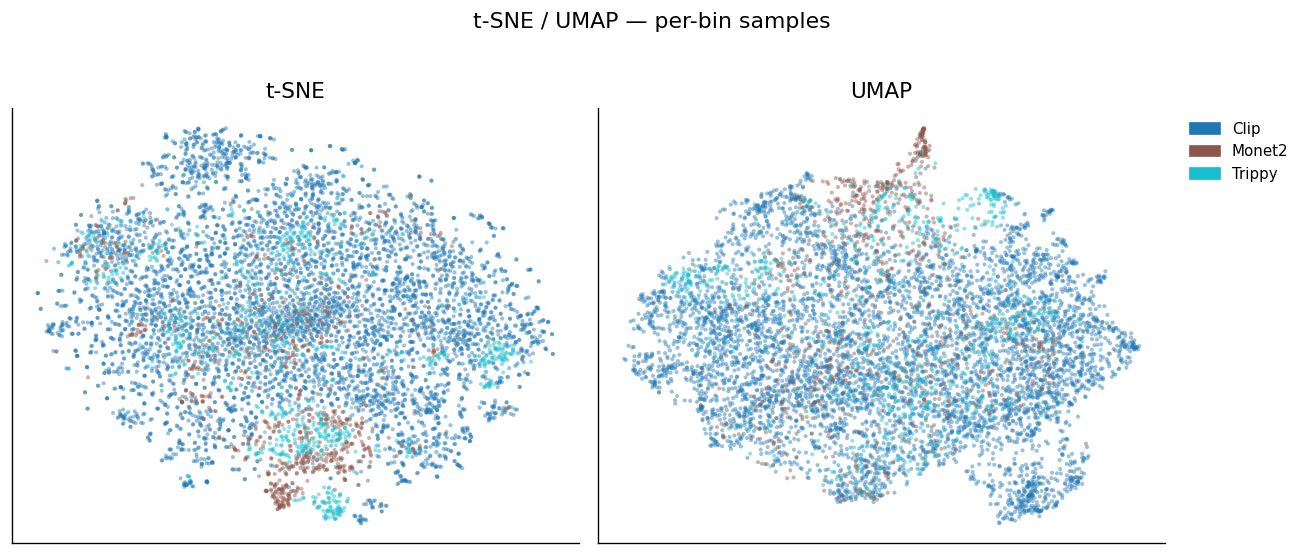

In [11]:
fig, axes = plt.subplots(1, 2 if R_umap is not None else 1,
                         figsize=(11 if R_umap is not None else 6, 4.5))
if R_umap is None: axes = [axes]
for ax, name, emb in [(axes[0], 't-SNE', R_tsne)] + (
    [(axes[1], 'UMAP', R_umap)] if R_umap is not None else []):
    for lbl in unique_labels:
        m = labels_sub == lbl
        ax.scatter(emb[m,0], emb[m,1], color=label_to_color[lbl],
                   alpha=0.45, s=6, edgecolors='none')
    ax.set_title(name); ax.set_xticks([]); ax.set_yticks([])
axes[-1].legend(handles=legend_patches, bbox_to_anchor=(1.02,1), loc='upper left', fontsize=9)
plt.suptitle('t-SNE / UMAP — per-bin samples', y=1.02)
plt.tight_layout(); plt.savefig('fig_ts_tsne_umap.png', dpi=150); plt.show()


## CEBRA — fed as a time series

Per-trial neural traces are concatenated in time, with stimulus type as the
auxiliary discrete label. This is what `offset10-model` is designed for.


pos: -0.9997 neg:  6.8069 total:  5.8072 temperature:  1.0000: 100%|██████████| 4000/4000 [11:39<00:00,  5.72it/s]


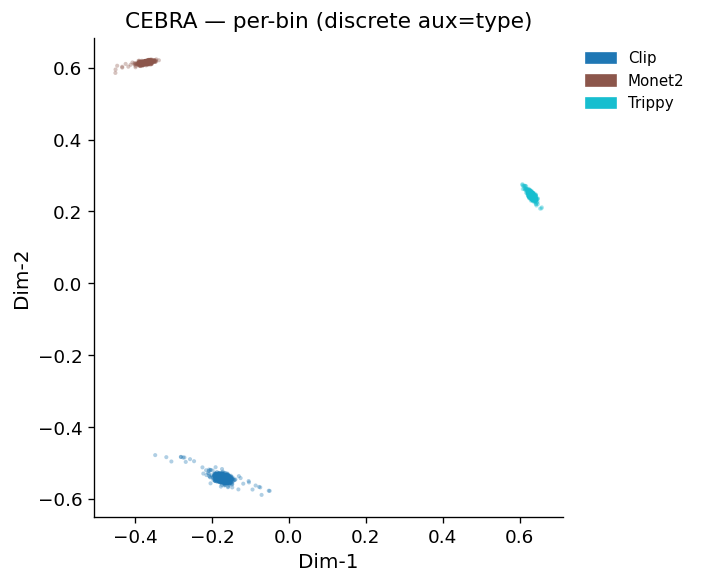

In [12]:
R_cebra = None
if CEBRA_AVAILABLE:
    try:
        # Sort by (trial_id, time_idx) so CEBRA sees coherent temporal chunks.
        order = np.lexsort((time_idx, trial_ids))
        R_ordered = R_scaled[order].astype(np.float32)
        y_ordered = y[order].astype(np.int64)

        cb = cebra.CEBRA(
            model_architecture='offset10-model',
            batch_size=512,
            learning_rate=3e-4,
            temperature=1.0,
            output_dimension=8,
            max_iterations=4000,
            distance='cosine',
            conditional='discrete',     # type label as discrete aux
            device='cpu',
            verbose=True,
        )
        cb.fit(R_ordered, y_ordered)
        R_cebra_ord = cb.transform(R_ordered)
        # Undo the reorder so R_cebra aligns with labels / trial_ids / etc.
        inv = np.empty_like(order); inv[order] = np.arange(len(order))
        R_cebra = R_cebra_ord[inv]

        fig, ax = plt.subplots(figsize=(6,5))
        for lbl in unique_labels:
            m = labels == lbl
            ax.scatter(R_cebra[m,0], R_cebra[m,1], color=label_to_color[lbl],
                       alpha=0.35, s=6, edgecolors='none')
        ax.set_title('CEBRA — per-bin (discrete aux=type)')
        ax.set_xlabel('Dim-1'); ax.set_ylabel('Dim-2')
        ax.legend(handles=legend_patches, bbox_to_anchor=(1.02,1), loc='upper left', fontsize=9)
        plt.tight_layout(); plt.savefig('fig_ts_cebra.png', dpi=150); plt.show()
    except Exception as e:
        print(f'CEBRA failed: {e}')
        R_cebra = None
else:
    print('CEBRA not installed')


## Quantitative evaluation

**Key change vs the original**: the classifier is evaluated in the
full PCA-`N_PCS_FOR_CLF`-dimensional space, not in the 2-D embedding.
2-D t-SNE / UMAP coordinates are visualization-only; their pairwise
distances are not metric-faithful, so it is meaningless to feed them to a
linear classifier.

We use `GroupKFold(groups=trial_ids)` so no fold contains bins from a
trial that also appears in the training set. Without this, the classifier
trivially memorizes within-trial autocorrelation.


In [13]:
gkf = GroupKFold(n_splits=N_CV_SPLITS)
clf = LogisticRegression(max_iter=2000, C=1.0, random_state=SEED,
                         class_weight='balanced', n_jobs=-1)

# Feature spaces to score
feature_sets = {
    'PCA-2D'                : R_pca[:, :2],
    f'PCA-{N_PCS_FOR_CLF}D' : R_pca[:, :N_PCS_FOR_CLF],
}
if R_cebra is not None:
    feature_sets['CEBRA-8D'] = R_cebra

scores = {}
print('Cross-validated balanced accuracy (GroupKFold by trial):')
print(f"  chance={chance_level:.3f}   majority={majority_frac:.3f}\n")
for name, X in feature_sets.items():
    bal = cross_val_score(clf, X, y, cv=gkf, groups=trial_ids,
                          scoring='balanced_accuracy', n_jobs=-1)
    f1  = cross_val_score(clf, X, y, cv=gkf, groups=trial_ids,
                          scoring='f1_macro', n_jobs=-1)
    scores[name] = (bal.mean(), bal.std(), f1.mean(), f1.std())
    print(f'  {name:14s}  bal_acc = {bal.mean():.4f} ± {bal.std():.4f}'
          f'   F1 = {f1.mean():.4f} ± {f1.std():.4f}')


Cross-validated balanced accuracy (GroupKFold by trial):
  chance=0.333   majority=0.766

  PCA-2D          bal_acc = 0.4689 ± 0.0396   F1 = 0.3814 ± 0.0185
  PCA-50D         bal_acc = 0.8159 ± 0.0251   F1 = 0.7408 ± 0.0161
  CEBRA-8D        bal_acc = 1.0000 ± 0.0000   F1 = 1.0000 ± 0.0000


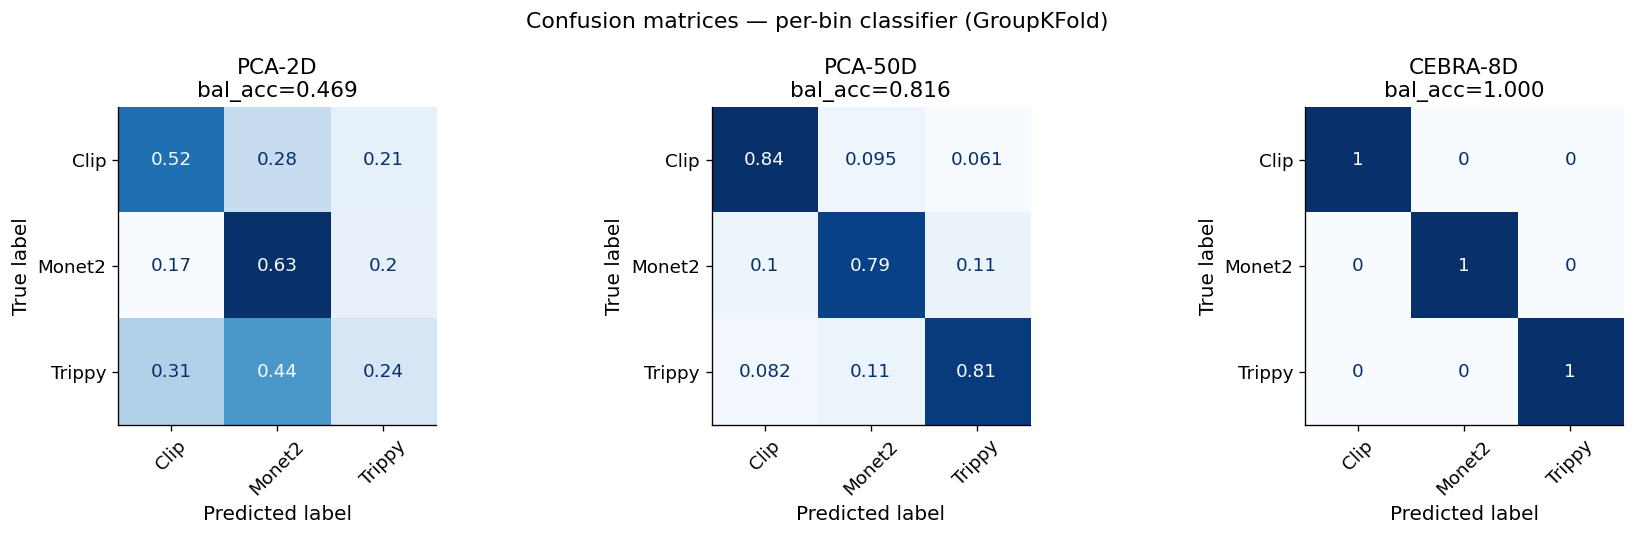

In [14]:
# Confusion matrices (predictions via grouped CV)
fig, axes = plt.subplots(1, len(feature_sets), figsize=(5*len(feature_sets), 4.5))
if len(feature_sets) == 1: axes = [axes]
for ax, (name, X) in zip(axes, feature_sets.items()):
    y_pred = cross_val_predict(clf, X, y, cv=gkf, groups=trial_ids, n_jobs=-1)
    cm = confusion_matrix(y, y_pred, normalize='true')
    ConfusionMatrixDisplay(cm, display_labels=le.classes_).plot(
        ax=ax, colorbar=False, cmap='Blues', xticks_rotation=45)
    bacc = scores[name][0]
    ax.set_title(f'{name}\nbal_acc={bacc:.3f}')
plt.suptitle('Confusion matrices — per-bin classifier (GroupKFold)')
plt.tight_layout(); plt.savefig('fig_ts_confusion.png', dpi=150); plt.show()


## Shuffle control

Shuffle labels **at the trial level** (so within-trial correlation is
preserved in the null) and re-run the classifier. This is the honest null
for per-bin data.


Real bal_acc      : 0.8159
Null mean ± sd    : 0.3320 ± 0.0249
Null max          : 0.3883
Empirical p       : 0.0000  (N_SHUFFLES=50)


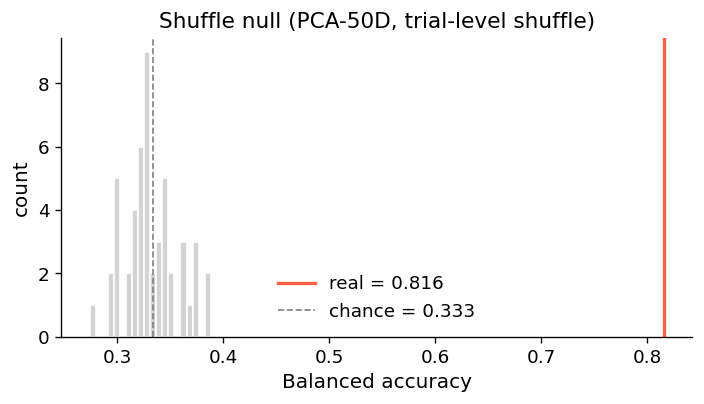

In [15]:
# Map trial -> label, shuffle that mapping.
unique_trials = np.unique(trial_ids)
trial_to_y = {t: y[trial_ids == t][0] for t in unique_trials}

X_top = R_pca[:, :N_PCS_FOR_CLF]
real_bal = scores[f'PCA-{N_PCS_FOR_CLF}D'][0]

null_bal = []
rng_s = np.random.default_rng(SEED)
for i in range(N_SHUFFLES):
    shuffled_y_per_trial = rng_s.permutation([trial_to_y[t] for t in unique_trials])
    t_to_yshuf = dict(zip(unique_trials, shuffled_y_per_trial))
    y_shuf = np.array([t_to_yshuf[t] for t in trial_ids])
    bal = cross_val_score(clf, X_top, y_shuf, cv=gkf, groups=trial_ids,
                          scoring='balanced_accuracy', n_jobs=-1).mean()
    null_bal.append(bal)
null_bal = np.array(null_bal)

print(f'Real bal_acc      : {real_bal:.4f}')
print(f'Null mean ± sd    : {null_bal.mean():.4f} ± {null_bal.std():.4f}')
print(f'Null max          : {null_bal.max():.4f}')
p = (null_bal >= real_bal).mean()
print(f'Empirical p       : {p:.4f}  (N_SHUFFLES={N_SHUFFLES})')

fig, ax = plt.subplots(figsize=(6,3.5))
ax.hist(null_bal, bins=20, color='lightgray', edgecolor='white')
ax.axvline(real_bal, color='tomato', lw=2, label=f'real = {real_bal:.3f}')
ax.axvline(chance_level, color='gray', ls='--', lw=1, label=f'chance = {chance_level:.3f}')
ax.set_xlabel('Balanced accuracy'); ax.set_ylabel('count')
ax.set_title(f'Shuffle null (PCA-{N_PCS_FOR_CLF}D, trial-level shuffle)')
ax.legend(); plt.tight_layout(); plt.savefig('fig_ts_shuffle.png', dpi=150); plt.show()


## Within-trial temporal structure

A cheap sanity check that per-bin information is real: colour the PCA
scatter by bin-within-trial. If V1 codes anything stimulus-locked, nearby
bins should sit near each other, and early/late bins should differ.


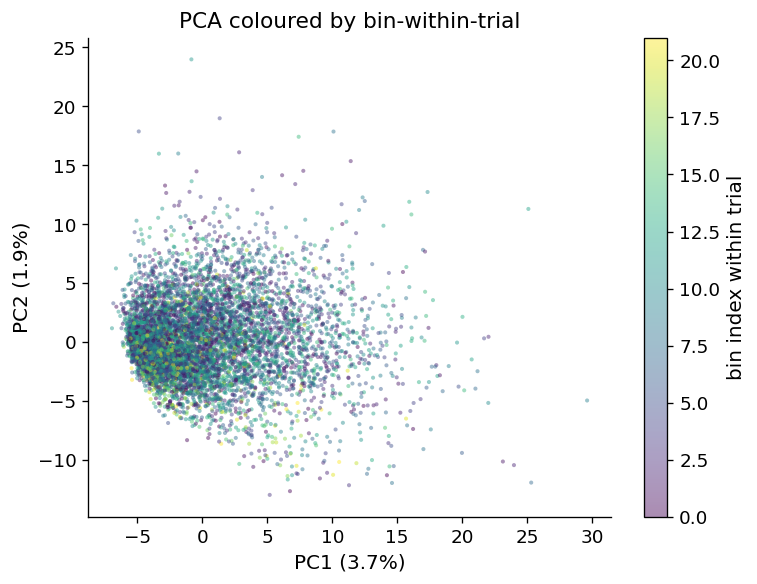

In [16]:
fig, ax = plt.subplots(figsize=(6.5, 5))
sc = ax.scatter(R_pca[:,0], R_pca[:,1], c=time_idx, cmap='viridis',
                alpha=0.45, s=6, edgecolors='none')
plt.colorbar(sc, ax=ax, label='bin index within trial')
ax.set_xlabel(f'PC1 ({ev[0]*100:.1f}%)'); ax.set_ylabel(f'PC2 ({ev[1]*100:.1f}%)')
ax.set_title('PCA coloured by bin-within-trial')
plt.tight_layout(); plt.savefig('fig_ts_pca_by_time.png', dpi=150); plt.show()


## Layer-specific (L4 and L2/3)

Re-run PCA + classifier restricted to each layer. We share the
per-bin sample structure so the only thing that changes is which neurons
the activity matrix is built from.


In [17]:
def run_layer(layer_name, mask):
    R_l   = R_clean[:, mask]
    sc_l  = StandardScaler().fit_transform(R_l)
    act   = sc_l.std(axis=1) > 1e-6
    sc_l  = sc_l[act]
    y_l   = y[act]
    tr_l  = trial_ids[act]
    n_pc  = min(N_PCS_FOR_CLF, sc_l.shape[1]-1, sc_l.shape[0]-1)
    pca_l = PCA(n_components=n_pc, random_state=SEED).fit_transform(sc_l)
    bal = cross_val_score(clf, pca_l, y_l, cv=gkf, groups=tr_l,
                          scoring='balanced_accuracy', n_jobs=-1)
    f1  = cross_val_score(clf, pca_l, y_l, cv=gkf, groups=tr_l,
                          scoring='f1_macro', n_jobs=-1)
    return {'layer': layer_name, 'n_neurons': int(mask.sum()),
            'n_samples': int(len(y_l)),
            'bal_acc': bal.mean(), 'bal_acc_std': bal.std(),
            'f1': f1.mean(), 'f1_std': f1.std()}

results = []
for ln in ['L2/3', 'L4', 'L5', 'L6']:
    m = (trusted_meta_clean['layer'] == ln).values
    if m.sum() < 10:
        print(f'Skipping {ln} (only {m.sum()} neurons)'); continue
    print(f'Running {ln} ({m.sum()} neurons)...')
    results.append(run_layer(ln, m))

results.append({'layer': 'ALL', 'n_neurons': R_clean.shape[1],
                'n_samples': len(y),
                'bal_acc': scores[f'PCA-{N_PCS_FOR_CLF}D'][0],
                'bal_acc_std': scores[f'PCA-{N_PCS_FOR_CLF}D'][1],
                'f1': scores[f'PCA-{N_PCS_FOR_CLF}D'][2],
                'f1_std': scores[f'PCA-{N_PCS_FOR_CLF}D'][3]})

df_layer = pd.DataFrame(results)
print('\nLayer-wise results:')
print(df_layer.to_string(index=False))


Running L2/3 (220 neurons)...
Running L4 (257 neurons)...
Running L5 (89 neurons)...
Running L6 (12 neurons)...

Layer-wise results:
layer  n_neurons  n_samples  bal_acc  bal_acc_std       f1   f1_std
 L2/3        220       7520 0.732667     0.022061 0.643368 0.010366
   L4        257       7520 0.735296     0.041483 0.639015 0.028837
   L5         89       7520 0.585951     0.065617 0.472831 0.037292
   L6         12       7520 0.482110     0.047655 0.389881 0.027562
  ALL        579       7520 0.815884     0.025069 0.740832 0.016096


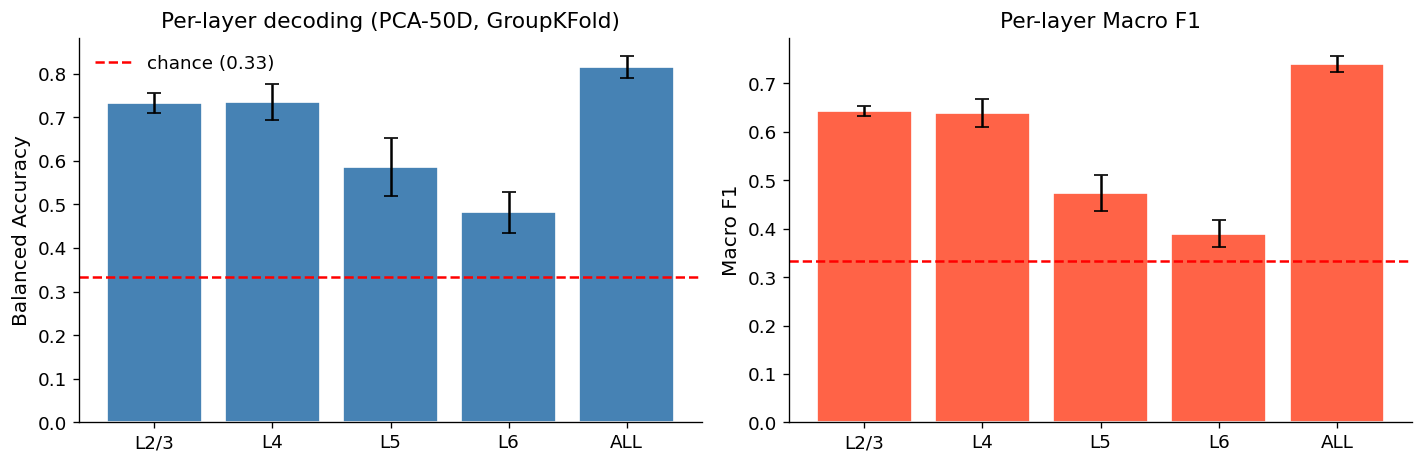

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
x = np.arange(len(df_layer))
axes[0].bar(x, df_layer['bal_acc'], yerr=df_layer['bal_acc_std'],
            color='steelblue', edgecolor='white', capsize=4)
axes[0].axhline(chance_level, color='red', ls='--', label=f'chance ({chance_level:.2f})')
axes[0].set_xticks(x); axes[0].set_xticklabels(df_layer['layer'])
axes[0].set_ylabel('Balanced Accuracy')
axes[0].set_title(f'Per-layer decoding (PCA-{N_PCS_FOR_CLF}D, GroupKFold)')
axes[0].legend()

axes[1].bar(x, df_layer['f1'], yerr=df_layer['f1_std'],
            color='tomato', edgecolor='white', capsize=4)
axes[1].axhline(chance_level, color='red', ls='--')
axes[1].set_xticks(x); axes[1].set_xticklabels(df_layer['layer'])
axes[1].set_ylabel('Macro F1')
axes[1].set_title('Per-layer Macro F1')

plt.tight_layout(); plt.savefig('fig_ts_layers.png', dpi=150); plt.show()


## Summary

- Every temporal bin is an individual sample → temporal structure is
  retained and the sample count is large enough for non-linear DR to
  behave.
- Classifier is evaluated in PCA-50 space, not in a 2-D embedding.
- Cross-validation is `GroupKFold(groups=trial_ids)`, so the model can
  never see another bin from the same trial during training.
- The shuffle null shuffles labels at the **trial** level, which is the
  honest null when within-trial bins are correlated.
- Layer-restricted versions reuse the per-bin/grouped-CV pipeline.

If decoding is still around chance in PCA-50 space with grouped CV, the
conclusion is that V1 population mean rate (even with time preserved at
~5-frame resolution) doesn't separate these *coarse stimulus categories*
on this session — and the next experiment to try is decoding **specific
stimulus identity** within a category (e.g. clip-ID, or grating
orientation for the Monet subset).
